# T1 diagnostic: AOM/PMT delay

Plots the wide-window capture from `t1_test.py diagnostic` (`run_delay_diagnostic()`) --
a single readout event captured from well before its trigger (t=0, the AWG marker edge at
the start of the 300ns RF burst that drives the AOM) to well after, so the actual
combined AOM-turn-on + acoustic-transit + PMT-response + cabling delay can be read
directly off the trace instead of guessed from datasheets. No live instrument connection
needed here -- everything comes from the saved `.npy`/metadata files.

This data reflects two fixes (see notes.md): (1) `RTB2004.run()` was querying the sample
rate before switching into `ACQuire:MEMory MANual` mode, giving the wrong rate for a
non-default `scale_s` -- metadata now reads `sample_rate_hz=312e6`, `t0_s=-4.9728e-6`,
matching the requested `DIAGNOSTIC_START_S=-5e-6` closely. (2) The normal sequence's two
identically-marked readout events made it ambiguous which pulse the scope was capturing --
`run_delay_diagnostic()` now uses `upload_diagnostic_sequence()` (no calibration stage, only
one readout per loop), confirmed by a now-uniform ~33.9us inter-trigger spacing in the
timetable. The resulting delay estimate (0.399us) matches the earlier ambiguous-sequence
measurement (0.389us) almost exactly, as expected -- the delay is a property of the
AOM/PMT/cabling chain, not of which readout instance produced it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rtb2004 import make_t_from_metadata

DATA_DIR = "D:/t1"
NAME = "diagnostic_delay"

READOUT_PULSE_S = 300e-9  # the readout RF burst's duration, starting at t=0

In [2]:
waveform = np.load(f"{DATA_DIR}/{NAME}.npy")
t_s = make_t_from_metadata(f"{DATA_DIR}/{NAME}_metadata.txt")
t_us = t_s * 1e6

print(f"waveform shape: {waveform.shape} "
      f"({waveform.shape[0]} segments, {waveform.shape[1]} samples/segment)")
print(f"window: {t_us[0]:+.3f} us to {t_us[-1]:+.3f} us relative to the readout trigger "
      f"({t_us[-1] - t_us[0]:.3f} us wide)")

mean_waveform = waveform.mean(axis=0)
std_waveform = waveform.std(axis=0)
n_segments = waveform.shape[0]
sem_waveform = std_waveform / np.sqrt(n_segments)

waveform shape: (100, 10000) (100 segments, 10000 samples/segment)
window: -4.973 us to +27.075 us relative to the readout trigger (32.048 us wide)


## Estimate the delay

Baseline = the averaged trace's own point-to-point jitter *before* the trigger (t < 0) --
using the trace's own scatter as the noise reference, rather than the raw per-segment std,
since averaging `n_segments` segments already reduces jitter roughly like `1/sqrt(N)` (see
the earlier SEM-vs-raw-std discussion in `analyze_data.ipynb`). Delay estimate = first
point at/after t=0 where the averaged trace departs from that baseline by more than
`THRESHOLD_SIGMA` times the baseline jitter.

In [3]:
THRESHOLD_SIGMA = 5.0

baseline_mask = t_s < 0
if not np.any(baseline_mask):
    raise ValueError(
        "no samples before t=0 in this capture -- widen DIAGNOSTIC_START_S "
        "(more negative) in t1_test.py and re-run the diagnostic"
    )

baseline_mean = mean_waveform[baseline_mask].mean()
baseline_jitter = mean_waveform[baseline_mask].std()

after_trigger = np.where(t_s >= 0)[0]
crossing = after_trigger[np.abs(mean_waveform[after_trigger] - baseline_mean) > THRESHOLD_SIGMA * baseline_jitter]

if len(crossing) == 0:
    print(f"No {THRESHOLD_SIGMA}-sigma departure from baseline found after t=0 -- "
          f"either the delay is longer than this window, the signal is weaker than "
          f"{THRESHOLD_SIGMA} sigma above baseline jitter, or something else is wrong. "
          f"Look at the plot below directly.")
    estimated_delay_s = None
else:
    estimated_delay_s = t_s[crossing[0]]
    print(f"baseline: {baseline_mean:.5f} V, jitter (1 sigma): {baseline_jitter:.6f} V")
    print(f"estimated AOM/PMT delay: {estimated_delay_s*1e6:.3f} us after the readout trigger")

baseline: -0.01016 V, jitter (1 sigma): 0.001151 V
estimated AOM/PMT delay: 0.399 us after the readout trigger


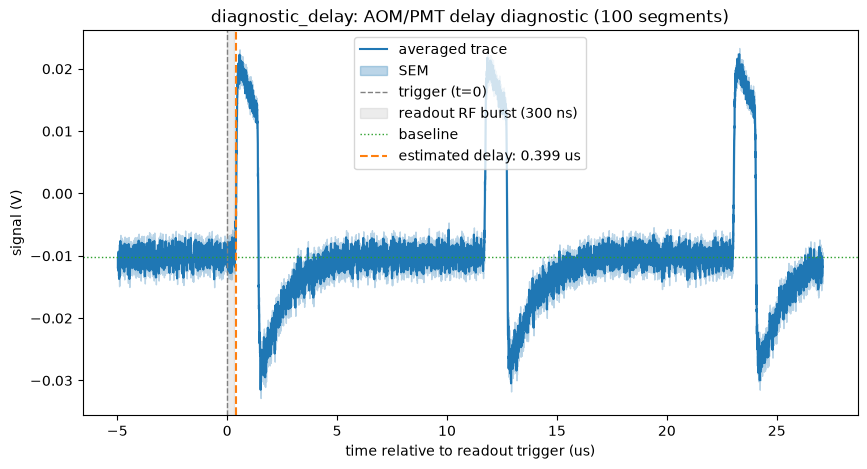

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_us, mean_waveform, color="C0", label="averaged trace")
ax.fill_between(t_us, mean_waveform - sem_waveform, mean_waveform + sem_waveform,
                 color="C0", alpha=0.3, label="SEM")

ax.axvline(0, color="gray", ls="--", lw=1, label="trigger (t=0)")
ax.axvspan(0, READOUT_PULSE_S * 1e6, color="gray", alpha=0.15,
            label=f"readout RF burst ({READOUT_PULSE_S*1e9:.0f} ns)")
ax.axhline(baseline_mean, color="C2", ls=":", lw=1, label="baseline")

if estimated_delay_s is not None:
    ax.axvline(estimated_delay_s * 1e6, color="C1", ls="--",
                label=f"estimated delay: {estimated_delay_s*1e6:.3f} us")

ax.set_xlabel("time relative to readout trigger (us)")
ax.set_ylabel("signal (V)")
ax.set_title(f"{NAME}: AOM/PMT delay diagnostic ({n_segments} segments)")
ax.legend()
plt.show()